# ML Component - Neuro-Symbolic Counterfactuals

This notebook covers the machine learning part of the project. The idea is to train a neural network on the Adult Income dataset that predicts whether someone earns more than 50k. This model is then used by the ASP pipeline to check whether a given person's features lead to a high or low income prediction.

## Step 1 - Imports

Just the standard stuff we need: pandas for loading the data, PyTorch for the model and training, and DataLoader to handle batching.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), ".."))  # so we can import from project root

import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

print("Libraries loaded successfully")

Libraries loaded successfully


## Step 2 - Loading and Preprocessing the Data

The dataset is the UCI Adult Income dataset which has around 32k rows. We only use 5 features: age, sex, hours per week, education level and occupation.

Age and sex are fixed - meaning they cant be changed in a counterfactual. The other three (hours, education, occupation) are the editable ones that the ASP solver can try modifying.

The raw CSV has string values so we map them to numeric codes that match the ASP vocabulary. Any rows with values we dont have mappings for get dropped.

In [2]:
# Maps from raw CSV strings to simplified labels used in the ASP file
EDUCATION_MAP = {
    "HS-grad":   "highschool",
    "Bachelors": "bachelors",
    "Masters":   "masters",
}
OCCUPATION_MAP = {
    "Tech-support": "tech", "Exec-managerial": "tech", "Prof-specialty": "tech",
    "Sales": "sales",
    "Adm-clerical": "admin", "Protective-serv": "admin",
    "Priv-house-serv": "admin", "Armed-Forces": "admin",
    "Craft-repair": "bluecollar", "Machine-op-inspct": "bluecollar",
    "Transport-moving": "bluecollar", "Handlers-cleaners": "bluecollar",
    "Farming-fishing": "bluecollar", "Other-service": "bluecollar",
}
SEX_MAP = {"Male": "male", "Female": "female"}

# Numeric encoding for the MLP
EDUCATION_ENCODE  = {"highschool": 0, "bachelors": 1, "masters": 2}
OCCUPATION_ENCODE = {"tech": 0, "sales": 1, "admin": 2, "bluecollar": 3}
SEX_ENCODE        = {"male": 0, "female": 1}

INPUT_SIZE = 5

# Normalisation so all inputs are in [0, 1]
AGE_NORM = 100.0;  HOURS_NORM = 100.0
EDUCATION_NORM = 2.0;  OCCUPATION_NORM = 3.0


def load_data(path):
    columns = [
        "age", "workclass", "fnlwgt", "education", "education-num",
        "marital-status", "occupation", "relationship", "race", "sex",
        "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
    ]
    df = pd.read_csv(path, header=None, names=columns, skipinitialspace=True)
    df = df[["age", "education", "hours-per-week", "occupation", "sex", "income"]]
    df = df.rename(columns={"hours-per-week": "hours"})
    df["education"]  = df["education"].map(EDUCATION_MAP)
    df["occupation"] = df["occupation"].map(OCCUPATION_MAP)
    df["sex"]        = df["sex"].map(SEX_MAP)
    df = df.dropna()
    df["income"] = df["income"].apply(lambda x: 1 if ">50K" in str(x) else 0)
    return df.reset_index(drop=True)


def encode_df(df):
    X = pd.DataFrame({
        "age":        df["age"].astype(float)                               / AGE_NORM,
        "education":  df["education"].map(EDUCATION_ENCODE).astype(float)   / EDUCATION_NORM,
        "hours":      df["hours"].astype(float)                             / HOURS_NORM,
        "occupation": df["occupation"].map(OCCUPATION_ENCODE).astype(float) / OCCUPATION_NORM,
        "sex":        df["sex"].map(SEX_ENCODE).astype(float),
    })
    return torch.tensor(X.values, dtype=torch.float32), torch.tensor(df["income"].values, dtype=torch.float32)


# Load and display the data
DATA_PATH = "../data/adult.csv"
df = load_data(DATA_PATH)

print(f"Total rows after cleaning: {len(df)}")
print(f"\nIncome class balance:")
print(df["income"].value_counts().rename({0: "<=50K", 1: ">50K"}).to_string())
print(f"\nFirst 5 rows:")
df.head()

Total rows after cleaning: 16825

Income class balance:
income
<=50K    12079
>50K      4746

First 5 rows:


,age,education,hours,occupation,sex,income
0,39,bachelors,40,admin,male,0
1,50,bachelors,13,tech,male,0
2,38,highschool,40,bluecollar,male,0
3,28,bachelors,40,tech,female,0
4,37,masters,40,tech,female,0


## Step 3 - Model Definition

We use a simple MLP (multilayer perceptron) with 2 hidden layers. Nothing too complex, just enough to get reasonable accuracy on a tabular dataset like this.

The architecture is: 5 inputs → 32 neurons (ReLU) → 16 neurons (ReLU) → 1 output (Sigmoid)

The sigmoid at the end gives a value between 0 and 1. If its >= 0.5 we predict income > 50k, otherwise <= 50k.

In [3]:
class MLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

print("MLP architecture:")
print(MLP(INPUT_SIZE))

MLP architecture:
MLP(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [4]:
RANDOM_SEED = 42
TEST_SPLIT  = 0.15
VAL_SPLIT   = 0.15  # 15% of total each, so 70% train / 15% val / 15% test

X, y = encode_df(df)

torch.manual_seed(RANDOM_SEED)
n_total = len(X)
n_test  = int(n_total * TEST_SPLIT)
n_val   = int(n_total * VAL_SPLIT)
n_train = n_total - n_test - n_val
perm    = torch.randperm(n_total)

X_train, y_train = X[perm[:n_train]],               y[perm[:n_train]]
X_val,   y_val   = X[perm[n_train:n_train+n_val]],  y[perm[n_train:n_train+n_val]]
X_test,  y_test  = X[perm[n_train+n_val:]],         y[perm[n_train+n_val:]]

# Save test split for final evaluation
torch.save({"X": X_test, "y": y_test}, "../ml/test_data.pt")

print(f"Training set:   {n_train} examples")
print(f"Validation set: {n_val} examples")
print(f"Test set:       {n_test} examples")
print(f"Test split saved to ml/test_data.pt")

Training set:   11779 examples
Validation set: 2523 examples
Test set:       2523 examples
Test split saved to ml/test_data.pt


## Step 5 - Training

We train for 100 epochs using BCELoss (standard loss for binary classification) and Adam with lr=0.001. Batch size is 256.

Every 10 epochs we check both the training and validation loss/accuracy so we can see if the model is actually learning or just overfitting. The graphs at the end show both curves together which makes it easier to spot any issues.

Epoch   1/100  |  train loss: 0.5958  val loss: 0.5961  |  train acc: 71.5%  val acc: 71.6%
Epoch  10/100  |  train loss: 0.4819  val loss: 0.4832  |  train acc: 76.9%  val acc: 76.5%
Epoch  20/100  |  train loss: 0.4662  val loss: 0.4683  |  train acc: 78.1%  val acc: 78.0%
Epoch  30/100  |  train loss: 0.4604  val loss: 0.4629  |  train acc: 78.4%  val acc: 78.0%
Epoch  40/100  |  train loss: 0.4562  val loss: 0.4590  |  train acc: 78.5%  val acc: 78.4%
Epoch  50/100  |  train loss: 0.4524  val loss: 0.4550  |  train acc: 78.7%  val acc: 78.4%
Epoch  60/100  |  train loss: 0.4497  val loss: 0.4529  |  train acc: 78.9%  val acc: 78.3%
Epoch  70/100  |  train loss: 0.4471  val loss: 0.4512  |  train acc: 78.7%  val acc: 78.2%
Epoch  80/100  |  train loss: 0.4450  val loss: 0.4500  |  train acc: 78.8%  val acc: 78.2%
Epoch  90/100  |  train loss: 0.4444  val loss: 0.4494  |  train acc: 78.8%  val acc: 78.3%
Epoch 100/100  |  train loss: 0.4443  val loss: 0.4492  |  train acc: 78.9%  val

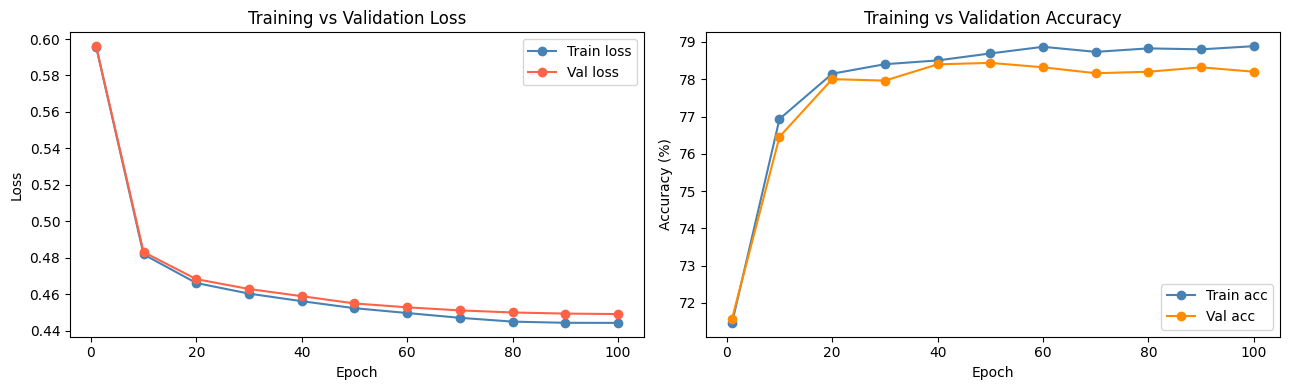

In [5]:
import matplotlib.pyplot as plt

EPOCHS     = 100
BATCH_SIZE = 256
LR         = 0.001

train_loader = DataLoader(TensorDataset(X_train, y_train),
                          batch_size=BATCH_SIZE, shuffle=True)

model     = MLP(INPUT_SIZE)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# Tracked every 10 epochs (and epoch 1)
checkpoint_epochs  = []
train_loss_history = []
val_loss_history   = []
train_acc_history  = []
val_acc_history    = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(X_batch).squeeze(), y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(X_batch)

    avg_train_loss = total_loss / n_train

    if epoch % 10 == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            train_out   = model(X_train).squeeze()
            train_loss  = criterion(train_out, y_train).item()
            train_acc   = ((train_out >= 0.5).float() == y_train).float().mean().item()

            val_out     = model(X_val).squeeze()
            val_loss    = criterion(val_out, y_val).item()
            val_acc     = ((val_out >= 0.5).float() == y_val).float().mean().item()

        checkpoint_epochs.append(epoch)
        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)
        train_acc_history.append(train_acc)
        val_acc_history.append(val_acc)

        print(f"Epoch {epoch:>3}/{EPOCHS}  |  "
              f"train loss: {train_loss:.4f}  val loss: {val_loss:.4f}  |  "
              f"train acc: {train_acc*100:.1f}%  val acc: {val_acc*100:.1f}%")
        model.train()

print("\nTraining complete.")

# --- Graph 1: Training loss vs Validation loss ---
# --- Graph 2: Training accuracy vs Validation accuracy ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(checkpoint_epochs, train_loss_history, color="steelblue",  marker="o", label="Train loss")
ax1.plot(checkpoint_epochs, val_loss_history,   color="tomato",     marker="o", label="Val loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training vs Validation Loss")
ax1.legend()

ax2.plot(checkpoint_epochs, [v * 100 for v in train_acc_history], color="steelblue",  marker="o", label="Train acc")
ax2.plot(checkpoint_epochs, [v * 100 for v in val_acc_history],   color="darkorange", marker="o", label="Val acc")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Training vs Validation Accuracy")
ax2.legend()

plt.tight_layout()
plt.show()

## Step 6 - Final Test Accuracy

The test set was never used during training or validation so this gives a fair measure of how well the model actually generalises. We also save the model weights here so the pipeline can load them.

In [6]:
model.eval()
with torch.no_grad():
    preds    = (model(X_test).squeeze() >= 0.5).float()
    accuracy = (preds == y_test).float().mean().item()

print(f"Test accuracy: {accuracy * 100:.1f}%")
print(f"Correct:       {int((preds == y_test).sum())} / {n_test}")

torch.save(model.state_dict(), "../ml/model.pth")
print("Model saved to ml/model.pth")

Test accuracy: 79.1%
Correct:       1995 / 2523
Model saved to ml/model.pth
